# ImageNet事前訓練拡散モデルを医療画像分類で用いる

はじめに医療データセットに対してResNet50で分類を行う。
なお事前に得ていた事前訓練済みの分類機を用いる。データセットはkaggleのデータセットを用いる。

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm  # これを追加

DATA_DIR = '/mnt/data1/gotou/projects/Medical/kaggledata'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test')

# データ拡張（学習時のみ）
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PCamDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img_id = self.labels.iloc[idx, 0]
        label = self.labels.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

labels_df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(labels_df, test_size=0.1, random_state=42, stratify=labels_df['label'])

train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, train_transform)
val_dataset = PCamDataset(TRAIN_IMG_DIR, val_df, val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet50.fc = nn.Linear(resnet50.fc.in_features, 1)
model = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

In [2]:
# Evaluate only the first N validation images
USE_FIRST_N = 100
val_df_small = val_df.iloc[:USE_FIRST_N].copy()
val_dataset_small = PCamDataset(TRAIN_IMG_DIR, val_df_small, val_transform)
val_loader_small = DataLoader(val_dataset_small, batch_size=32, shuffle=False, num_workers=4)
print(f"Using first {USE_FIRST_N} validation images ({len(val_dataset_small)} samples).")

Using first 100 validation images (100 samples).


In [3]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth


In [4]:
import torch
import torch.nn as nn

# --- 攻撃関数 ---
import torch.nn.functional as F

import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

# 前提: device, mean, std が外部で定義されている（投稿の定義をそのまま使えます）
# MEAN = np.array([...]); STD = np.array([...])
# mean = torch.tensor(MEAN).view(1,3,1,1).to(device)
# std  = torch.tensor(STD).view(1,3,1,1).to(device)

def denormalize(x, mean, std):
    # normalized -> pixel [0,1]
    return x * std + mean

def renormalize(x_pixel, mean, std):
    # pixel [0,1] -> normalized
    return (x_pixel - mean) / std

def fgsm_attack_improved(model, images, labels, epsilon_pixel, device,
                         mean_tensor=None, std_tensor=None, return_preds=True):
    """
    FGSM attack that respects per-channel normalization.
    Args:
      model: nn.Module, expects normalized inputs (same normalization used here)
      images: normalized tensor [B,C,H,W] (already normalized by mean/std)
      labels: tensor [B] (0/1) or shape [B,1]
      epsilon_pixel: float (e.g. 8/255) or tensor broadcastable to channels (pixel-scale)
      device: torch.device
      mean_tensor, std_tensor: tensors shaped [1,C,1,1] on device (if None, must be global)
      return_preds: if True, also return predicted labels on adversarial images
    Returns:
      adv_images: tensor [B,C,H,W] (normalized, detached)
      adv_preds (optional): LongTensor [B] predicted labels on adv_images (cpu)
    """
    # use provided mean/std or expect global variables `mean`/`std`
    if mean_tensor is None or std_tensor is None:
        # these should exist in your scope (as in your snippet)
        mean_tensor_local = mean
        std_tensor_local = std
    else:
        mean_tensor_local = mean_tensor
        std_tensor_local = std_tensor

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    # model output: assume logits for binary classification -> shape [B] or [B,1]
    outputs = model(images)
    if outputs.ndim > 1 and outputs.shape[1] == 1:
        outputs = outputs.squeeze(1)  # [B]
    # binary cross entropy with logits
    loss = F.binary_cross_entropy_with_logits(outputs, labels.float())
    model.zero_grad()
    loss.backward()
    grad = images.grad.data  # gradient in normalized space

    # sign of gradient in normalized space
    grad_sign = grad.sign()

    # convert epsilon_pixel (pixel scale: 0..1) -> normalized-space epsilon per channel
    # support scalar epsilon_pixel or iterable per-channel
    if not torch.is_tensor(epsilon_pixel):
        eps_pixel_tensor = torch.tensor(epsilon_pixel, dtype=images.dtype, device=device)
    else:
        eps_pixel_tensor = epsilon_pixel.to(device).to(images.dtype)

    # make eps_norm shaped [1,C,1,1]
    if eps_pixel_tensor.ndim == 0:
        eps_norm = (eps_pixel_tensor / std_tensor_local).view(1, -1, 1, 1)
    elif eps_pixel_tensor.ndim == 1 and eps_pixel_tensor.numel() == std_tensor_local.shape[1]:
        eps_norm = (eps_pixel_tensor.view(1, -1, 1, 1) / std_tensor_local)
    else:
        # fallback: try to broadcast
        eps_norm = (eps_pixel_tensor / std_tensor_local)

    # create adversarial images in normalized space
    adv_images = images + eps_norm * grad_sign

    # clamp in pixel space
    adv_pixel = denormalize(adv_images, mean_tensor_local, std_tensor_local)
    adv_pixel = torch.clamp(adv_pixel, 0.0, 1.0)

    # back to normalized space
    adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
    adv_images.requires_grad = False

    if return_preds:
        with torch.no_grad():
            adv_out = model(adv_images)
            if adv_out.ndim > 1 and adv_out.shape[1] == 1:
                adv_out = adv_out.squeeze(1)
            adv_probs = torch.sigmoid(adv_out)
            adv_preds = (adv_probs > 0.5).long().cpu()
        # cleanup
        del grad, grad_sign, adv_out, adv_pixel, eps_norm, eps_pixel_tensor, loss
        torch.cuda.empty_cache()
        return adv_images, adv_preds

    # cleanup
    del grad, grad_sign, adv_pixel, eps_norm, eps_pixel_tensor, loss
    torch.cuda.empty_cache()
    return adv_images





In [5]:
# evaluate_clean_and_fgsm(model, val_loader, device, epsilon_pixel=30/255, mean=mean, std=std)
# original_acc, adversarial_acc = evaluate_clean_and_fgsm(model, val_loader, device, epsilon_pixel=0.01, mean=mean, std=std)

/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded classifier and ddpm (ddpm_out epoch10).


Eval loop (first 100): 100%|██████████| 4/4 [00:55<00:00, 13.84s/it]



==== Results ====
Total samples evaluated: 100
Clean accuracy:     0.9900
Adv (FGSM) accuracy:0.5300
Purified accuracy:  0.8400
Saved example images to: purify_examples
- Individual images: purify_examples/clean, purify_examples/adversarial, purify_examples/purified
- Triplets per image: purify_examples/triplets

Confusion Matrix Analysis


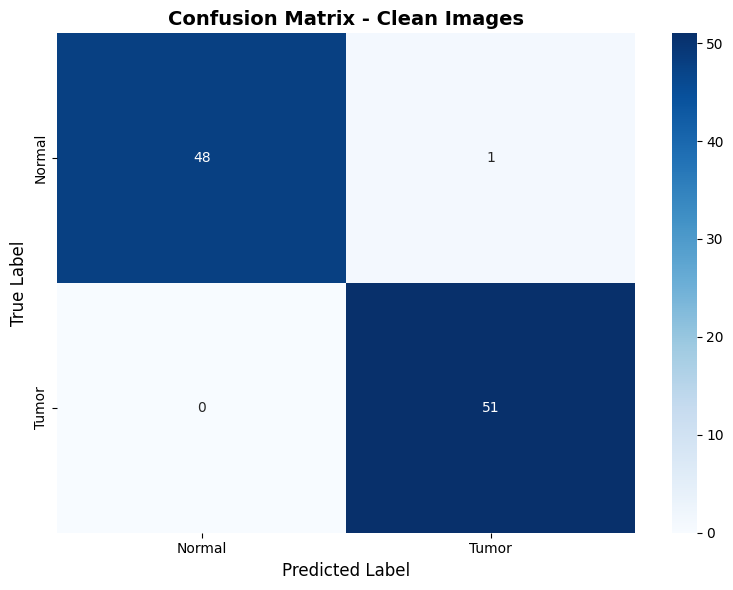


Confusion Matrix - Clean Images:
  True Negatives:  48
  False Positives: 1
  False Negatives: 0
  True Positives:  51
  Precision: 0.9808
  Recall:    1.0000
  F1-Score:  0.9903


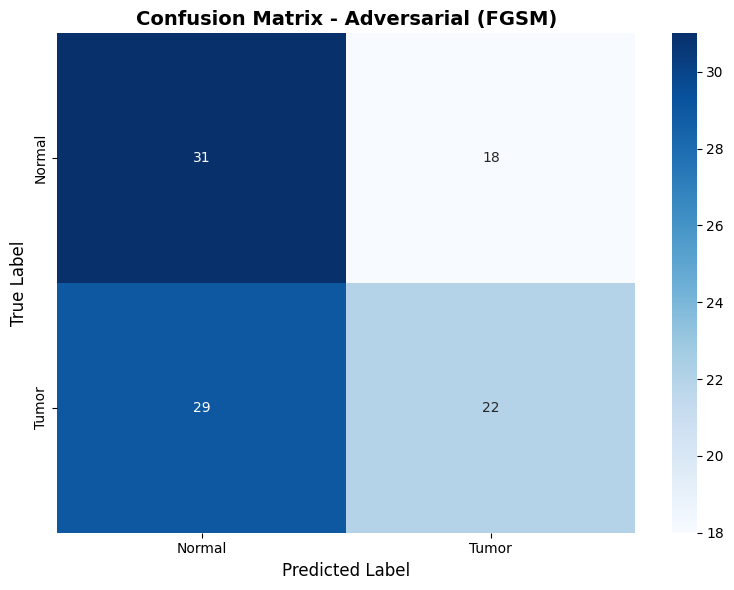


Confusion Matrix - Adversarial (FGSM):
  True Negatives:  31
  False Positives: 18
  False Negatives: 29
  True Positives:  22
  Precision: 0.5500
  Recall:    0.4314
  F1-Score:  0.4835


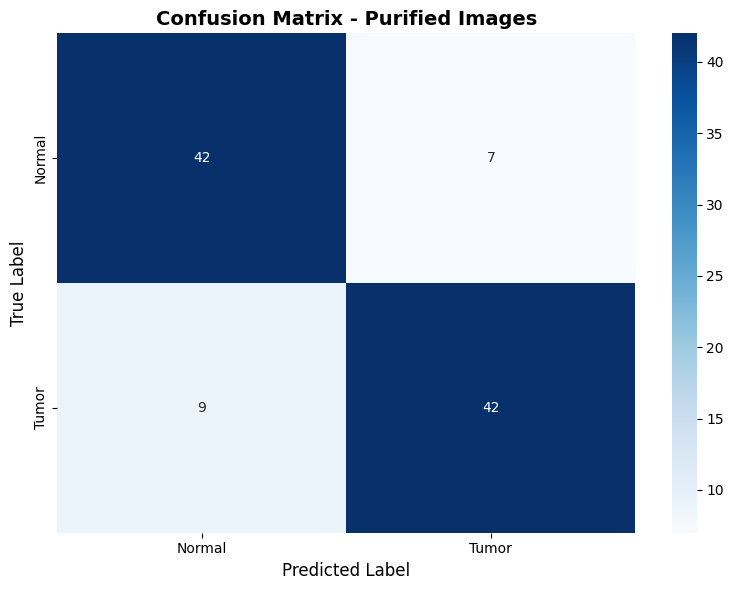


Confusion Matrix - Purified Images:
  True Negatives:  42
  False Positives: 7
  False Negatives: 9
  True Positives:  42
  Precision: 0.8571
  Recall:    0.8235
  F1-Score:  0.8400


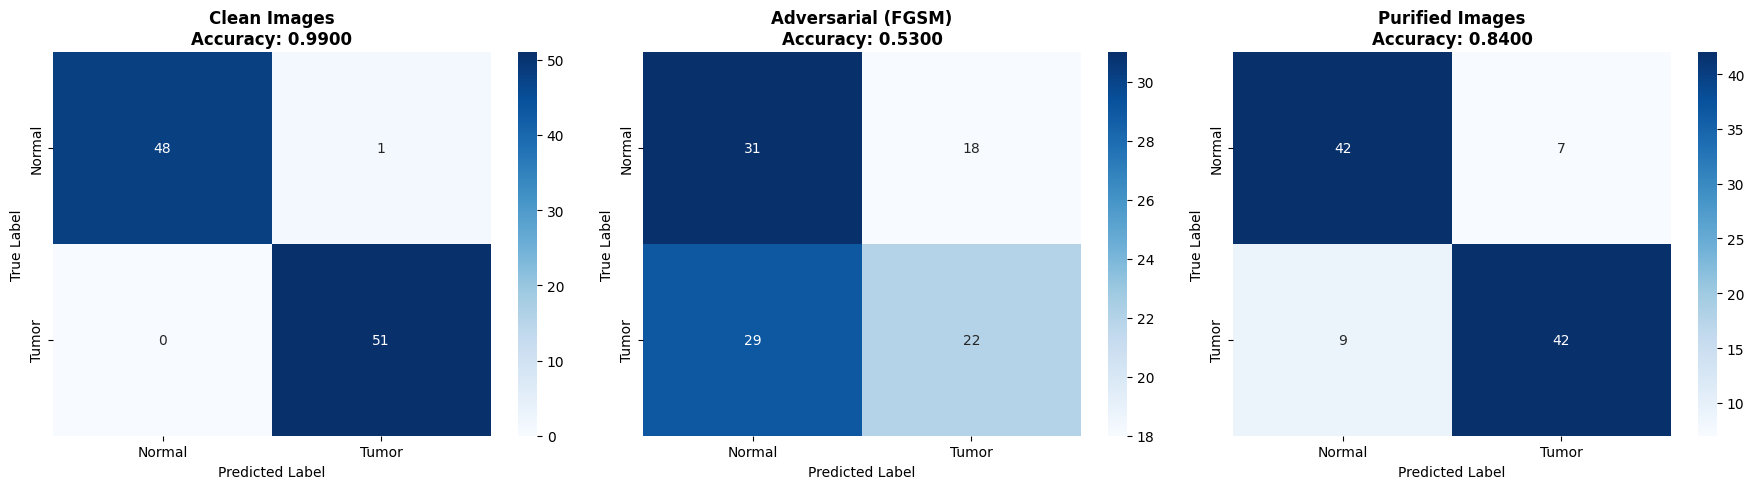


✅ All confusion matrices saved to: purify_examples


In [6]:
# ddpm_purify_eval_pipeline.py
import os
import torch
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
from tqdm import tqdm
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ---------- Basic device / paths ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 学習済みDDPM（ddpm.pyで学習したチェックポイント）
ddpm_ckpt = "/mnt/data1/gotou/projects/Medical/kaggledata/ddpm_out/ddpm_epoch10.pth"
clf_ckpt  = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"

# --- モデル定義（ddpm.pyと一致） ---
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=None):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        self.norm2 = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()
        if time_emb_dim is not None:
            self.time_mlp = nn.Sequential(
                nn.Linear(time_emb_dim, out_ch),
                nn.SiLU()
            )
        else:
            self.time_mlp = None
        self.act = nn.SiLU()
    def forward(self, x, t_emb=None):
        h = self.norm1(self.conv1(x))
        if self.time_mlp is not None and t_emb is not None:
            time_emb = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
            h = h + time_emb
        h = self.act(h)
        h = self.norm2(self.conv2(h))
        h = self.act(h)
        return h + self.skip(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim)
        )
        # down
        self.enc1 = ResidualBlock(in_ch, base_ch, time_emb_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch*2, 4, stride=2, padding=1)
        self.enc2 = ResidualBlock(base_ch*2, base_ch*2, time_emb_dim)
        self.down2 = nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1)
        self.enc3 = ResidualBlock(base_ch*4, base_ch*4, time_emb_dim)
        self.down3 = nn.Conv2d(base_ch*4, base_ch*8, 4, stride=2, padding=1)
        self.enc4 = ResidualBlock(base_ch*8, base_ch*8, time_emb_dim)
        self.down4 = nn.Conv2d(base_ch*8, base_ch*8, 4, stride=2, padding=1)
        # bottleneck
        self.bot1 = ResidualBlock(base_ch*8, base_ch*8, time_emb_dim)
        self.bot2 = ResidualBlock(base_ch*8, base_ch*8, time_emb_dim)
        # up
        self.up4 = nn.ConvTranspose2d(base_ch*8, base_ch*8, 4, stride=2, padding=1)
        self.dec4 = ResidualBlock(base_ch*16, base_ch*8, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(base_ch*8, base_ch*4, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(base_ch*4, base_ch*2, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(base_ch*2, base_ch, time_emb_dim)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 3, padding=1)
        )
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        e1 = self.enc1(x, t_emb)
        d1 = self.down1(e1)
        e2 = self.enc2(d1, t_emb)
        d2 = self.down2(e2)
        e3 = self.enc3(d2, t_emb)
        d3 = self.down3(e3)
        e4 = self.enc4(d3, t_emb)
        d4 = self.down4(e4)
        b = self.bot1(d4, t_emb)
        b = self.bot2(b, t_emb)
        u4 = self.up4(b)
        u4 = torch.cat([u4, e4], dim=1)
        u4 = self.dec4(u4, t_emb)
        u3 = self.up3(u4)
        u3 = torch.cat([u3, e3], dim=1)
        u3 = self.dec3(u3, t_emb)
        u2 = self.up2(u3)
        u2 = torch.cat([u2, e2], dim=1)
        u2 = self.dec2(u2, t_emb)
        u1 = self.up1(u2)
        u1 = torch.cat([u1, e1], dim=1)
        u1 = self.dec1(u1, t_emb)
        out = self.out_conv(u1)
        return out

# --- βスケジュール（学習時と同じ） ---
T_steps = 1000
betas = torch.linspace(1e-4, 0.02, T_steps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
# posterior_variance を使用
posterior_variance = torch.zeros_like(betas)
posterior_variance[1:] = betas[1:] * (1.0 - alphas_cumprod[:-1]) / (1.0 - alphas_cumprod[1:])
posterior_variance[0] = 1e-8

# --- load ddpm ---
ddpm = SimpleUNet(in_ch=3, base_ch=64, time_emb_dim=256).to(device)
ckpt = torch.load(ddpm_ckpt, map_location=device)
# ddpm.py の保存形式に対応
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    try:
        # EMA があれば優先的に使用
        if 'ema_state_dict' in ckpt and isinstance(ckpt['ema_state_dict'], dict):
            ddpm.load_state_dict(ckpt['ema_state_dict'], strict=False)
        else:
            ddpm.load_state_dict(ckpt['model_state_dict'])
    except Exception:
        ddpm.load_state_dict(ckpt['model_state_dict'])
else:
    ddpm.load_state_dict(ckpt)
ddpm.eval()

# --- diffusion_purify（x0再構成でノイズを抑える） ---
@torch.no_grad()
def diffusion_purify(x_adv_minus1to1, model, start_t=600, T_purify=100, eta=0.0, clamp_each_step=True, out_mode='x0'):
    """
    部分逆拡散後に x0_hat を再構成して返す（t>0で止めてもノイズを抑制）。
    out_mode: 'x0' で x0 推定を返す / 'x_t' で時刻 t のサンプルを返す
    """
    b = x_adv_minus1to1.size(0)
    t0 = torch.full((b,), start_t, device=device, dtype=torch.long)
    noise = torch.randn_like(x_adv_minus1to1)
    sqrt_a_bar_t0 = torch.sqrt(alphas_cumprod[t0]).view(-1,1,1,1)
    sqrt_1m_a_bar_t0 = torch.sqrt(1.0 - alphas_cumprod[t0]).view(-1,1,1,1)
    x_t = sqrt_a_bar_t0 * x_adv_minus1to1 + sqrt_1m_a_bar_t0 * noise

    eps_pred_final = None
    t_final = start_t
    for t_ in range(start_t, max(start_t - T_purify, 0), -1):
        t_batch = torch.full((b,), t_, device=device, dtype=torch.long)
        eps_pred = model(x_t, t_batch)
        alpha_t = alphas[t_]
        alpha_bar_t = alphas_cumprod[t_]
        # DDPMの平均
        mean = (1.0 / torch.sqrt(alpha_t)) * (x_t - (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t) * eps_pred)
        if t_ > 0:
            z = torch.randn_like(x_t)
            sigma = eta * torch.sqrt(posterior_variance[t_])
            x_t = mean + sigma * z
        else:
            x_t = mean
        if clamp_each_step:
            x_t = torch.clamp(x_t, -1.0, 1.0)
        # 最終時刻の記録
        eps_pred_final = eps_pred
        t_final = t_

    if out_mode == 'x0':
        # 最終時刻 t_final における x0 再構成
        alpha_bar_tf = alphas_cumprod[t_final]
        x0_hat = (x_t - torch.sqrt(1 - alpha_bar_tf) * eps_pred_final) / torch.sqrt(alpha_bar_tf + 1e-12)
        x0_hat = torch.clamp(x0_hat, -1.0, 1.0)
        return x0_hat
    else:
        return x_t

# ---------- normalization utilities ----------
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)
# DDPM学習時の正規化（mean=0.5, std=0.5 で [-1,1] スケール）
ddpm_mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1).to(device)
ddpm_std  = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1).to(device)

def unnormalize(x_norm):
    return x_norm * imagenet_std + imagenet_mean

def renormalize(x, mean, std):
    return (x - mean) / std

# 224x224での前後処理（DDPM学習時の正規化に合わせる）
def prepare_for_diffusion_from_norm(x_norm, target_size=224):
    x_pixel = unnormalize(x_norm)
    x_resized = F.interpolate(x_pixel, size=(target_size, target_size), mode="bilinear", align_corners=False)
    x_minus1to1 = (x_resized - ddpm_mean) / ddpm_std
    return x_minus1to1

def recover_from_diffusion_to_norm(x_minus1to1, out_size=224):
    x_pixel = x_minus1to1 * ddpm_std + ddpm_mean
    x_pixel = torch.clamp(x_pixel, 0.0, 1.0)
    x_resized = F.interpolate(x_pixel, size=(out_size, out_size), mode="bilinear", align_corners=False)
    x_norm = renormalize(x_resized, imagenet_mean, imagenet_std)
    return x_norm

# ---------- load classifier ----------
clf = models.resnet50(pretrained=False)
clf.fc = nn.Linear(clf.fc.in_features, 1)
clf.load_state_dict(torch.load(clf_ckpt, map_location=device))
clf = clf.to(device)
clf.eval()
print("Loaded classifier and ddpm (ddpm_out epoch10).")

# ---------- evaluation loop ----------
epsilon_pixel = 8/255.0
start_t = 75    # 浄化開始時刻
T_purify = 50    # 逆拡散反復数（短縮して高速化）
save_examples_dir = "purify_examples"
os.makedirs(save_examples_dir, exist_ok=True)
# per-image 出力用ディレクトリ
save_triplets_dir = os.path.join(save_examples_dir, "triplets")
save_clean_dir    = os.path.join(save_examples_dir, "clean")
save_adv_dir      = os.path.join(save_examples_dir, "adversarial")
save_pur_dir      = os.path.join(save_examples_dir, "purified")
for d in [save_triplets_dir, save_clean_dir, save_adv_dir, save_pur_dir]:
    os.makedirs(d, exist_ok=True)

# Use smaller loader if defined
EVAL_LOADER = val_loader_small if 'val_loader_small' in globals() else val_loader

# グローバルindex（val_df_smallがあれば画像IDに対応させる）
global_idx = 0

total = 0
correct_clean = 0
correct_adv = 0
correct_purified = 0

# 混同行列用のリスト
all_labels = []
all_preds_clean = []
all_preds_adv = []
all_preds_purified = []

# loop
for batch_idx, (images_norm, labels) in enumerate(tqdm(EVAL_LOADER, desc="Eval loop (first 100)")):
    images_norm = images_norm.to(device)
    labels = labels.to(device).long().view(-1)
    b = images_norm.size(0)
    total += b
    all_labels.extend(labels.cpu().numpy())

    # 1) clean prediction
    with torch.no_grad():
        logits_clean = clf(images_norm)
        if logits_clean.ndim > 1 and logits_clean.shape[1] == 1:
            logits_clean = logits_clean.squeeze(1)
        probs_clean = torch.sigmoid(logits_clean)
        preds_clean = (probs_clean > 0.5).long()
        correct_clean += (preds_clean.cpu() == labels.cpu()).sum().item()
        all_preds_clean.extend(preds_clean.cpu().numpy())

    # 2) adversarial example (FGSM)
    adv_images_norm, adv_preds_from_attack = fgsm_attack_improved(
        model=clf,
        images=images_norm,
        labels=labels,
        epsilon_pixel=epsilon_pixel,
        device=device,
        mean_tensor=imagenet_mean,
        std_tensor=imagenet_std,
        return_preds=True
    )
    adv_images_norm = adv_images_norm.to(device)
    adv_preds_from_attack = adv_preds_from_attack.to(device)
    correct_adv += (adv_preds_from_attack.cpu() == labels.cpu()).sum().item()
    all_preds_adv.extend(adv_preds_from_attack.cpu().numpy())

    # 3) prepare for diffusion & purify (x0再構成で返す)
    x_adv_for_diff = prepare_for_diffusion_from_norm(adv_images_norm, target_size=224)
    purified_minus1to1 = diffusion_purify(x_adv_for_diff, ddpm, start_t=start_t, T_purify=T_purify, eta=0.0, out_mode='x0')

    # 4) recover to classifier-normalized inputs and classify
    purified_norm = recover_from_diffusion_to_norm(purified_minus1to1, out_size=224)
    with torch.no_grad():
        logits_pur = clf(purified_norm)
        if logits_pur.ndim > 1 and logits_pur.shape[1] == 1:
            logits_pur = logits_pur.squeeze(1)
        probs_pur = torch.sigmoid(logits_pur)
        preds_pur = (probs_pur > 0.5).long()
        correct_purified += (preds_pur.cpu() == labels.cpu()).sum().item()
        all_preds_purified.extend(preds_pur.cpu().numpy())

    # 5) save per-image outputs (original/adv/purified) and triplet tiles
    clean_pixel = unnormalize(images_norm.detach()).clamp(0,1)
    adv_pixel   = unnormalize(adv_images_norm.detach()).clamp(0,1)
    pur_pixel   = (purified_minus1to1.detach() + 1.0) / 2.0
    # unify to 224x224 for saving
    clean_resized = F.interpolate(clean_pixel, size=(224,224), mode="bilinear", align_corners=False)
    adv_resized   = F.interpolate(adv_pixel,   size=(224,224), mode="bilinear", align_corners=False)
    pur_resized   = F.interpolate(pur_pixel,   size=(224,224), mode="bilinear", align_corners=False)

    for i in range(b):
        # 画像ID（もし小さい検証DFがあればそこから）
        if 'val_df_small' in globals():
            try:
                img_id = str(val_df_small.iloc[global_idx, 0])
            except Exception:
                img_id = f"idx{global_idx:05d}"
        else:
            img_id = f"idx{global_idx:05d}"
        label_int = int(labels[i].item())
        # individual saves
        save_image(clean_resized[i], os.path.join(save_clean_dir, f"{global_idx:05d}_{img_id}_label{label_int}_clean.png"))
        save_image(adv_resized[i],   os.path.join(save_adv_dir,   f"{global_idx:05d}_{img_id}_label{label_int}_adv.png"))
        save_image(pur_resized[i],   os.path.join(save_pur_dir,   f"{global_idx:05d}_{img_id}_label{label_int}_purified.png"))
        # triplet tile
        row = torch.cat([clean_resized[i], adv_resized[i], pur_resized[i]], dim=2)
        save_image(row, os.path.join(save_triplets_dir, f"{global_idx:05d}_{img_id}_triplet.png"))
        global_idx += 1

    # Also save a batch grid preview for first few batches
    if batch_idx < 5:
        n_save = min(8, b)
        rows = []
        for i in range(n_save):
            row = torch.cat([clean_resized[i], adv_resized[i], pur_resized[i]], dim=2)
            rows.append(row)
        grid = make_grid(torch.stack(rows), nrow=1)
        save_image(grid, os.path.join(save_examples_dir, f"triplets_batch{batch_idx}.png"))

# ---------- final results ----------
clean_acc = correct_clean / total
adv_acc = correct_adv / total
pur_acc = correct_purified / total

print("\n==== Results ====")
print(f"Total samples evaluated: {total}")
print(f"Clean accuracy:     {clean_acc:.4f}")
print(f"Adv (FGSM) accuracy:{adv_acc:.4f}")
print(f"Purified accuracy:  {pur_acc:.4f}")
print(f"Saved example images to: {save_examples_dir}")
print(f"- Individual images: {save_clean_dir}, {save_adv_dir}, {save_pur_dir}")
print(f"- Triplets per image: {save_triplets_dir}")

# ---------- 混同行列の計算と可視化 ----------
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0.0
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

print("\n" + "="*50)
print("Confusion Matrix Analysis")
print("="*50)

plot_confusion_matrix(
    all_labels, all_preds_clean,
    "Confusion Matrix - Clean Images",
    os.path.join(save_examples_dir, "confusion_matrix_clean.png")
)

plot_confusion_matrix(
    all_labels, all_preds_adv,
    "Confusion Matrix - Adversarial (FGSM)",
    os.path.join(save_examples_dir, "confusion_matrix_adversarial.png")
)

plot_confusion_matrix(
    all_labels, all_preds_purified,
    "Confusion Matrix - Purified Images",
    os.path.join(save_examples_dir, "confusion_matrix_purified.png")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm_clean = confusion_matrix(all_labels, all_preds_clean)
cm_adv = confusion_matrix(all_labels, all_preds_adv)
cm_pur = confusion_matrix(all_labels, all_preds_purified)
titles = ['Clean Images', 'Adversarial (FGSM)', 'Purified Images']
cms = [cm_clean, cm_adv, cm_pur]
accs = [clean_acc, adv_acc, pur_acc]
for ax, cm, title, acc in zip(axes, cms, titles, accs):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(save_examples_dir, 'confusion_matrix_comparison.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ All confusion matrices saved to: {save_examples_dir}")

# オプションA用: ImageNet正規化DDPM対応の評価コード

上記のセルは「オプションB（`[0.5]*3` 正規化DDPM用）」です。  
下記のセルは「オプションA（ImageNet正規化DDPM用）」で、正規化変換がシンプルになります。

**使い方:**
1. `case9.ipynb` でImageNet正規化版DDPMを学習完了後、下記セルを実行
2. `ddpm_ckpt` を `ddpm_checkpoints_imagenet/ddpm_pcam_imagenet_epoch50.pth` に変更してください

In [7]:
# オプションA用評価パイプライン（ImageNet正規化DDPM）
import os
import torch
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
from tqdm import tqdm
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ---------- Basic device / paths ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ImageNet正規化版DDPMのチェックポイント
ddpm_ckpt_imagenet = "/mnt/data1/gotou/kaggle/denoising/ddpm_checkpoints_imagenet/ddpm_pcam_imagenet_epoch20.pth"
clf_ckpt  = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"

# --- SimpleUNet (学習時と一致) ---
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1),
            nn.ReLU(),
        )
        self.middle = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*2, 3, 1, 1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_channels*2, base_channels, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, out_channels, 3, 1, 1)
        )

    def forward(self, x, t_emb):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

# --- βスケジュール（学習時と同じ） ---
T_steps = 1000
betas = torch.linspace(1e-4, 0.02, T_steps).to(device)
alphas = (1 - betas).to(device)
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

# --- load ddpm ---
ddpm_imagenet = SimpleUNet().to(device)
ddpm_imagenet.load_state_dict(torch.load(ddpm_ckpt_imagenet, map_location=device))
ddpm_imagenet.eval()

# --- diffusion_purify（ImageNet正規化空間で動作） ---
@torch.no_grad()
def diffusion_purify_imagenet(x_adv_norm, model, start_t=500, T_purify=100):
    """
    x_adv_norm: ImageNet正規化された敵対的画像 [B,C,H,W]
    戻り値: ImageNet正規化された浄化画像 [B,C,H,W]
    """
    b = x_adv_norm.size(0)
    t = torch.full((b,), start_t, device=device, dtype=torch.long)
    noise = torch.randn_like(x_adv_norm)

    sqrt_alphas_cumprod = alphas_cumprod[t] ** 0.5
    sqrt_one_minus_alphas_cumprod = (1 - alphas_cumprod[t]) ** 0.5
    x_t = sqrt_alphas_cumprod[:, None, None, None] * x_adv_norm + \
          sqrt_one_minus_alphas_cumprod[:, None, None, None] * noise

    step_range = range(start_t, max(start_t - T_purify, 0), -1)
    for t_ in step_range:
        t_batch = torch.full((b,), t_, device=device, dtype=torch.long)
        eps_pred = model(x_t, t_batch)
        beta_t = betas[t_]
        alpha_t = alphas[t_]
        alpha_bar_t = alphas_cumprod[t_]
        if t_ > 0:
            z = torch.randn_like(x_t)
        else:
            z = 0
        x_t = (1 / alpha_t**0.5) * (
            x_t - (1 - alpha_t) / (1 - alpha_bar_t)**0.5 * eps_pred
        ) + beta_t**0.5 * z

    return x_t  # ImageNet正規化されたまま返す

# ---------- normalization utilities ----------
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

def unnormalize_imagenet(x_norm):
    """ImageNet正規化を解除して [0,1] pixel値に戻す"""
    return x_norm * imagenet_std + imagenet_mean

# ---------- load classifier ----------
clf = models.resnet50(pretrained=False)
clf.fc = nn.Linear(clf.fc.in_features, 1)
clf.load_state_dict(torch.load(clf_ckpt, map_location=device))
clf = clf.to(device)
clf.eval()
print("Loaded classifier and ImageNet-normalized ddpm.")

# ---------- evaluation loop ----------
epsilon_pixel = 8/255.0
start_t = 500
T_purify = 100
save_examples_dir = "purify_examples_imagenet"
os.makedirs(save_examples_dir, exist_ok=True)

total = 0
correct_clean = 0
correct_adv = 0
correct_purified = 0

# 混同行列用のリスト
all_labels = []
all_preds_clean = []
all_preds_adv = []
all_preds_purified = []

# loop
for batch_idx, (images_norm, labels) in enumerate(tqdm(val_loader, desc="Eval loop (ImageNet norm)")):
    images_norm = images_norm.to(device)
    labels = labels.to(device).long().view(-1)
    b = images_norm.size(0)
    total += b

    # ラベル保存
    all_labels.extend(labels.cpu().numpy())

    # ---------- 1) clean prediction ----------
    with torch.no_grad():
        logits_clean = clf(images_norm)
        if logits_clean.ndim > 1 and logits_clean.shape[1] == 1:
            logits_clean = logits_clean.squeeze(1)
        probs_clean = torch.sigmoid(logits_clean)
        preds_clean = (probs_clean > 0.5).long()
        correct_clean += (preds_clean.cpu() == labels.cpu()).sum().item()
        all_preds_clean.extend(preds_clean.cpu().numpy())

    # ---------- 2) adversarial example (FGSM) ----------
    adv_images_norm, adv_preds_from_attack = fgsm_attack_improved(
        model=clf,
        images=images_norm,
        labels=labels,
        epsilon_pixel=epsilon_pixel,
        device=device,
        mean_tensor=imagenet_mean,
        std_tensor=imagenet_std,
        return_preds=True
    )
    adv_images_norm = adv_images_norm.to(device)
    adv_preds_from_attack = adv_preds_from_attack.to(device)
    correct_adv += (adv_preds_from_attack.cpu() == labels.cpu()).sum().item()
    all_preds_adv.extend(adv_preds_from_attack.cpu().numpy())

    # ---------- 3) purify（ImageNet正規化空間のまま処理） ----------
    purified_norm = diffusion_purify_imagenet(adv_images_norm, ddpm_imagenet, start_t=start_t, T_purify=T_purify)

    # ---------- 4) classify purified images ----------
    with torch.no_grad():
        logits_pur = clf(purified_norm)
        if logits_pur.ndim > 1 and logits_pur.shape[1] == 1:
            logits_pur = logits_pur.squeeze(1)
        probs_pur = torch.sigmoid(logits_pur)
        preds_pur = (probs_pur > 0.5).long()
        correct_purified += (preds_pur.cpu() == labels.cpu()).sum().item()
        all_preds_purified.extend(preds_pur.cpu().numpy())

    # ---------- save example triplets ----------
    if batch_idx < 5:
        n_save = min(8, b)
        clean_pixel = unnormalize_imagenet(images_norm[:n_save].detach()).clamp(0,1)
        adv_pixel   = unnormalize_imagenet(adv_images_norm[:n_save].detach()).clamp(0,1)
        pur_pixel   = unnormalize_imagenet(purified_norm[:n_save].detach()).clamp(0,1)

        rows = []
        for i in range(n_save):
            row = torch.cat([clean_pixel[i], adv_pixel[i], pur_pixel[i]], dim=2)
            rows.append(row)
        grid = make_grid(torch.stack(rows), nrow=1)
        save_image(grid, os.path.join(save_examples_dir, f"triplets_batch{batch_idx}.png"))

# ---------- final results ----------
clean_acc = correct_clean / total
adv_acc = correct_adv / total
pur_acc = correct_purified / total

print("\n==== Results (ImageNet Normalization) ====")
print(f"Total samples evaluated: {total}")
print(f"Clean accuracy:     {clean_acc:.4f}")
print(f"Adv (FGSM) accuracy:{adv_acc:.4f}")
print(f"Purified accuracy:  {pur_acc:.4f}")
print(f"Saved example images to: {save_examples_dir}")

# ---------- 混同行列の計算と可視化 ----------
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    # 詳細統計を表示
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0.0
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# 3つの混同行列を生成
print("\n" + "="*50)
print("Confusion Matrix Analysis (ImageNet Norm)")
print("="*50)

plot_confusion_matrix(
    all_labels, all_preds_clean,
    "Confusion Matrix - Clean Images",
    os.path.join(save_examples_dir, "confusion_matrix_clean.png")
)

plot_confusion_matrix(
    all_labels, all_preds_adv,
    "Confusion Matrix - Adversarial (FGSM)",
    os.path.join(save_examples_dir, "confusion_matrix_adversarial.png")
)

plot_confusion_matrix(
    all_labels, all_preds_purified,
    "Confusion Matrix - Purified Images (ImageNet Norm)",
    os.path.join(save_examples_dir, "confusion_matrix_purified.png")
)

# ---------- 3つの混同行列を並べて表示 ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_clean = confusion_matrix(all_labels, all_preds_clean)
cm_adv = confusion_matrix(all_labels, all_preds_adv)
cm_pur = confusion_matrix(all_labels, all_preds_purified)

titles = ['Clean Images', 'Adversarial (FGSM)', 'Purified Images']
cms = [cm_clean, cm_adv, cm_pur]
accs = [clean_acc, adv_acc, pur_acc]

for ax, cm, title, acc in zip(axes, cms, titles, accs):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(save_examples_dir, 'confusion_matrix_comparison.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ All confusion matrices saved to: {save_examples_dir}")

/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded classifier and ImageNet-normalized ddpm.


Eval loop (ImageNet norm):   0%|          | 3/688 [00:15<59:34,  5.22s/it]


KeyboardInterrupt: 